# Scalability experiments

In [442]:
import pandas as pd

df = pd.read_csv("results/legacy/scalabilityExperimentMSDv3.csv")

In [443]:
from pathlib import Path
import pandas as pd

df = pd.DataFrame()
for x in Path("results/remote").glob("*K*_n*.csv"):
    with open(x) as f:
        if len(f.readlines()):
            df = pd.concat([df, pd.read_csv(x)])

In [444]:
for x in df.columns:
    print(x)

risk
K
n
seed
gamma
alpha
epsilon
epsilon_scr
kappa
tau
max_candidates
n_screen_starts
n_support_starts
screen_maxiter
support_maxiter
stochastic_max_iter
stochastic_minibatch_size
methods
mcp_success
mcp_time_s
mcp_eta
mcp_regret1
mcp_regret2
mcp_has_profile
mcp_error
mcp_solver
mcp_candidate_index
mcp_support_eta
mcp_screen_eta
mcp_support_violation
mcp_residual_norm
mcp_objective
mcp_iterations
mcp_best_certificate_eta
screened_dual_success
screened_dual_time_s
screened_dual_eta
screened_dual_regret1
screened_dual_regret2
screened_dual_has_profile
screened_dual_error
screened_dual_solver
screened_dual_candidate_index
screened_dual_support_eta
screened_dual_screen_eta
screened_dual_support_violation
screened_dual_residual_norm
screened_dual_objective
screened_dual_iterations
screened_dual_best_certificate_eta
action_dual_success
action_dual_time_s
action_dual_eta
action_dual_regret1
action_dual_regret2
action_dual_has_profile
action_dual_error
action_dual_solver
action_dual_candidate

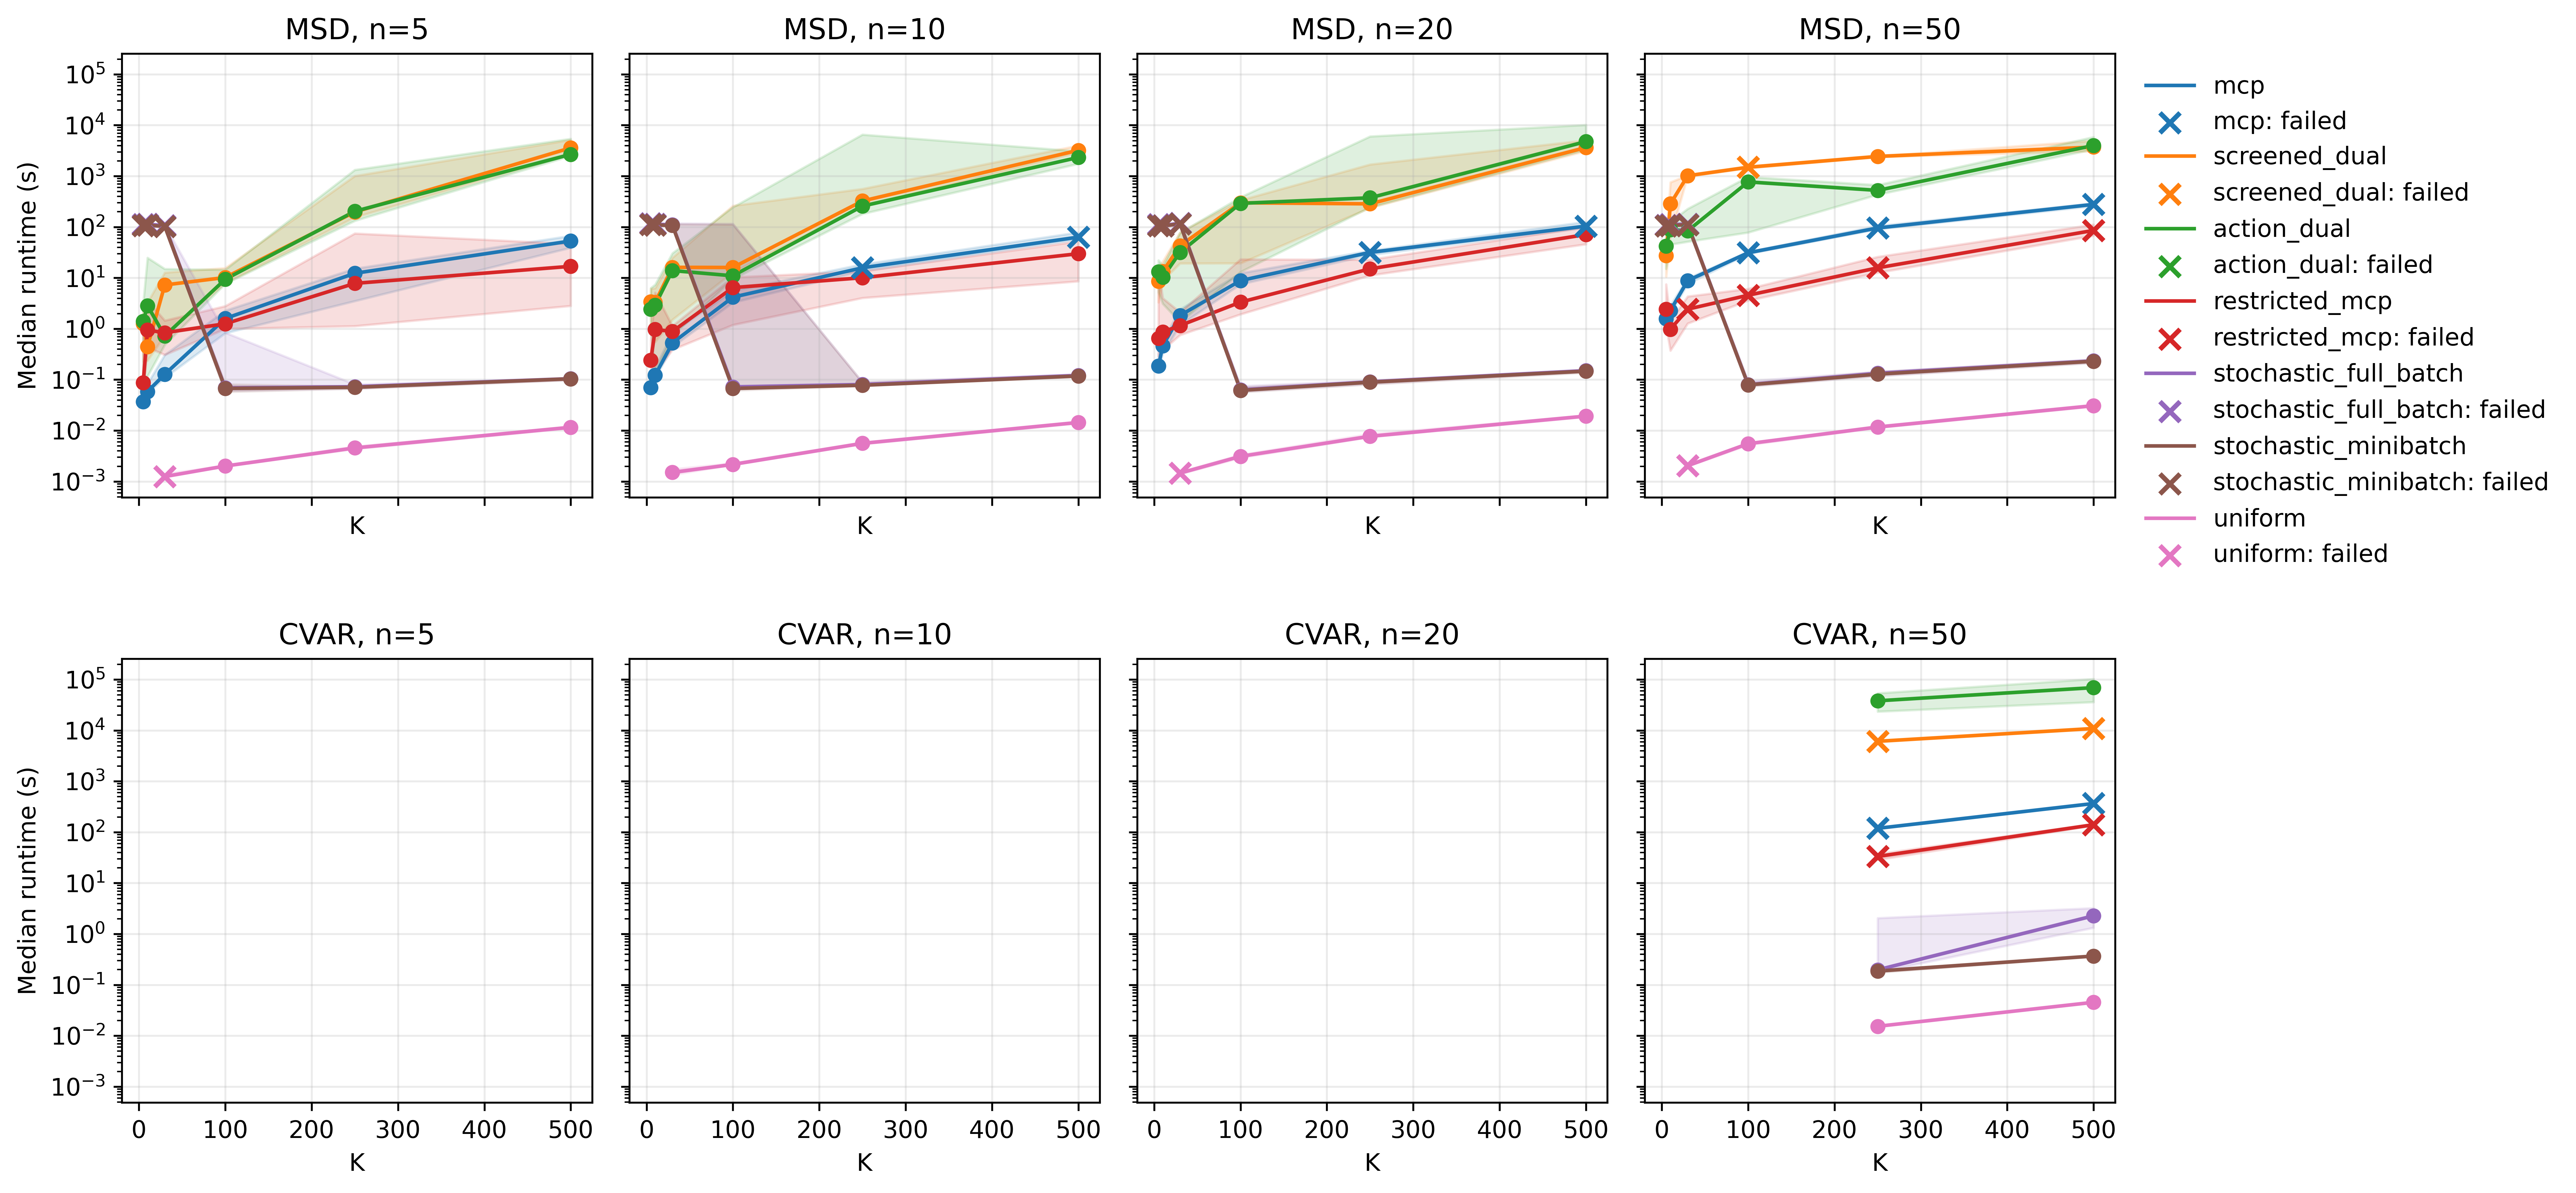

In [445]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]
risk_grid = ["msd", "cvar"]
uniform_df = pd.read_csv("results/uniform_profile_baseline.csv")

fig, axes = plt.subplots(
    len(risk_grid),
    len(n_grid),
    figsize=(15, 7),
    dpi=600,
    sharey=True,
    sharex=True,
)

methods = [m.strip() for m in df["methods"].iloc[0].split(",")]
if "uniform" not in methods:
    methods = methods + ["uniform"]
cmap = plt.get_cmap("tab10")
color_dict = {m: cmap(i % cmap.N) for i, m in enumerate(methods)}

for row, risk in enumerate(risk_grid):
    for col, n in enumerate(n_grid):
        ax = axes[row, col]
        s = df[(df["n"] == n) & (df["risk"] == risk)].sort_values("K")
        uniform_s = uniform_df.merge(
            s[["risk", "K", "n", "seed"]].drop_duplicates(),
            on=["risk", "K", "n", "seed"],
            how="inner",
        ).sort_values("K")

        for method in methods:
            method_s = uniform_s if method == "uniform" else s
            method_df = method_s.groupby("K", as_index=False).agg(
                **{
                    f"{method}_reps": ("seed", "count"),
                    f"{method}_time_median": (f"{method}_time_s", "median"),
                    f"{method}_time_q25": (
                        f"{method}_time_s",
                        lambda x: x.quantile(0.25),
                    ),
                    f"{method}_time_q75": (
                        f"{method}_time_s",
                        lambda x: x.quantile(0.75),
                    ),
                    f"{method}_eta_median": (f"{method}_eta", "median"),
                    f"{method}_succ_n": (f"{method}_success", "sum"),
                }
            )

            if method_df.empty:
                continue

            method_zero = method_df[f"{method}_succ_n"] == 0

            ax.plot(
                method_df["K"],
                method_df[f"{method}_time_median"],
                "-",
                label=method if row == 0 and col == len(n_grid) - 1 else "_nolegend_",
                color=color_dict[method],
            )
            ax.fill_between(
                method_df["K"],
                method_df[f"{method}_time_q25"],
                method_df[f"{method}_time_q75"],
                alpha=0.15,
                label="_nolegend_",
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[~method_zero, "K"],
                method_df.loc[~method_zero, f"{method}_time_median"],
                marker="o",
                s=28,
                zorder=4,
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[method_zero, "K"],
                method_df.loc[method_zero, f"{method}_time_median"],
                marker="x",
                s=70,
                linewidths=2.0,
                label=(
                    f"{method}: failed"
                    if row == 0 and col == len(n_grid) - 1
                    else "_nolegend_"
                ),
                zorder=5,
                color=color_dict[method],
            )

        ax.set_yscale("log")
        ax.set_title(f"{risk.upper()}, n={n}")
        ax.set_xlabel("K")
        ax.grid(alpha=0.25)

    axes[row, 0].set_ylabel(f"Median runtime (s)")

axes[0, -1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

KeyError: 'methods'

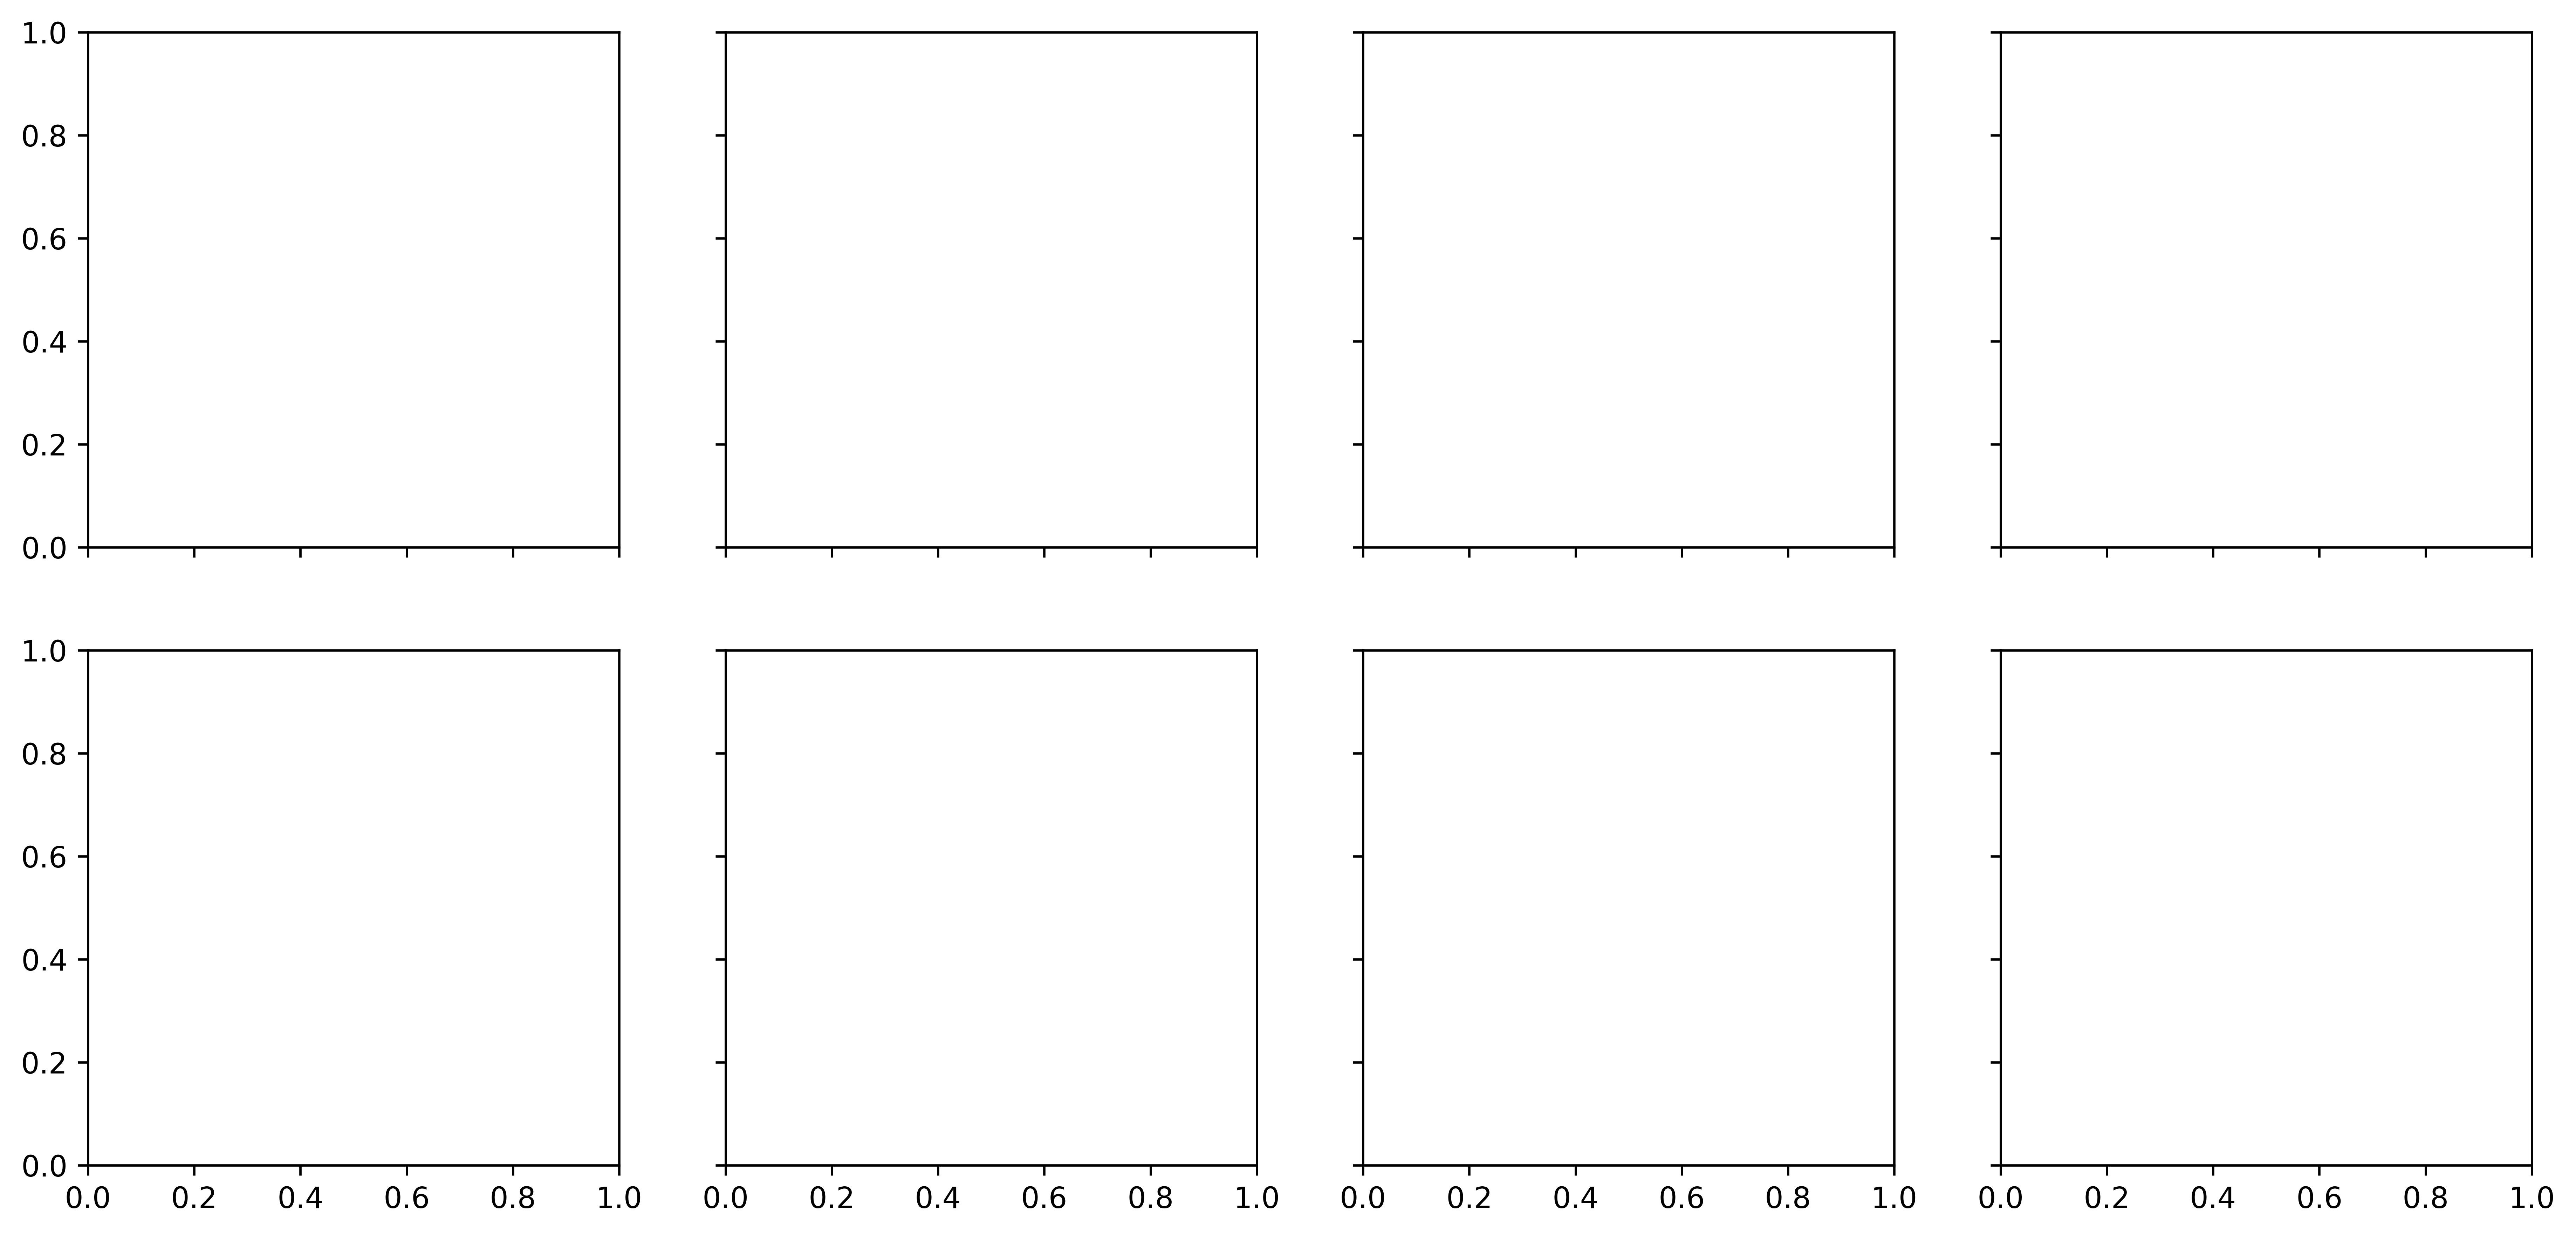

In [440]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]
risk_grid = ["msd", "cvar"]
uniform_df = pd.read_csv("results/uniform_profile_baseline.csv")

fig, axes = plt.subplots(
    len(risk_grid),
    len(n_grid),
    figsize=(15, 7),
    dpi=600,
    sharey=True,
    sharex=True,
)

methods = [m.strip() for m in df["methods"].iloc[0].split(",")]
if "uniform" not in methods:
    methods = methods + ["uniform"]
cmap = plt.get_cmap("tab10")
color_dict = {m: cmap(i % cmap.N) for i, m in enumerate(methods)}

for row, risk in enumerate(risk_grid):
    for col, n in enumerate(n_grid):
        ax = axes[row, col]
        s = df[(df["n"] == n) & (df["risk"] == risk)]
        uniform_s = uniform_df.merge(
            s[["risk", "K", "n", "seed"]].drop_duplicates(),
            on=["risk", "K", "n", "seed"],
            how="inner",
        )

        for method in methods:
            method_s = uniform_s if method == "uniform" else s
            method_df = (
                method_s.groupby("K", as_index=False)
                .agg(
                    **{
                        f"{method}_reps": ("seed", "count"),
                        f"{method}_succ_n": (f"{method}_success", "sum"),
                    }
                )
                .sort_values("K")
            )

            if method_df.empty:
                continue

            method_df[f"{method}_succ_rate"] = (
                method_df[f"{method}_succ_n"] / method_df[f"{method}_reps"]
            )

            ax.plot(
                method_df["K"],
                method_df[f"{method}_succ_rate"],
                "o-",
                label=method if row == 0 and col == len(n_grid) - 1 else "_nolegend_",
                color=color_dict[method],
            )

        ax.set_title(f"{risk.upper()}, n={n}")
        ax.set_xlabel("K")
        ax.grid(alpha=0.25)

    axes[row, 0].set_ylabel("Success rate")

axes[0, -1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

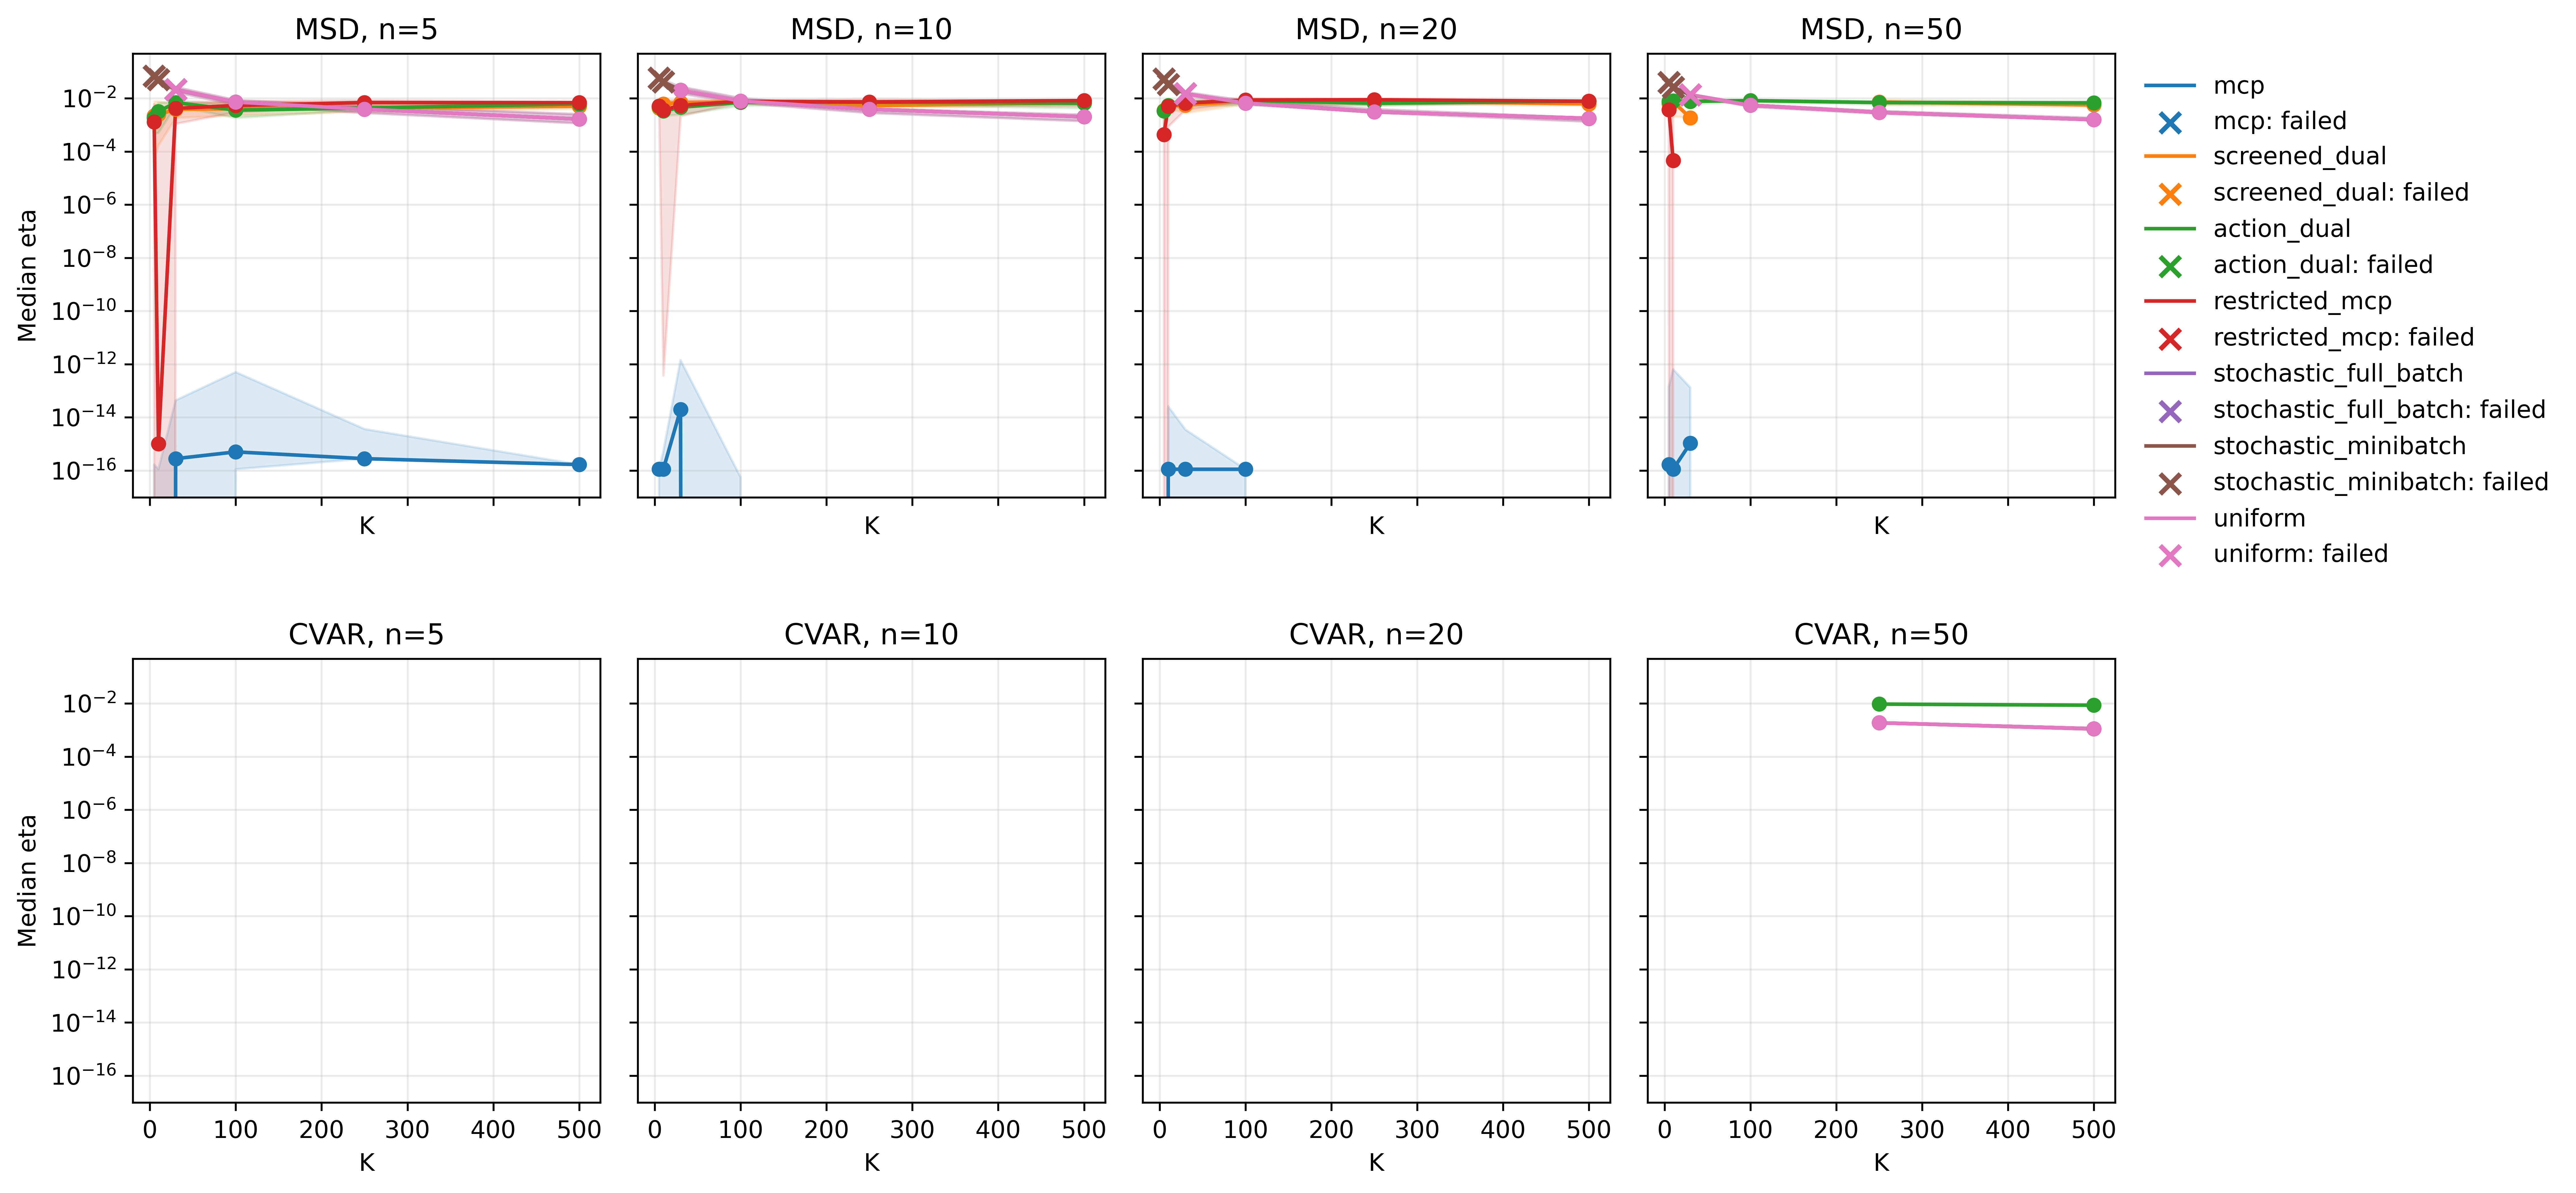

In [398]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]
risk_grid = ["msd", "cvar"]
uniform_df = pd.read_csv("results/uniform_profile_baseline.csv")

fig, axes = plt.subplots(
    len(risk_grid),
    len(n_grid),
    figsize=(15, 7),
    dpi=600,
    sharey=True,
    sharex=True,
)

methods = [m.strip() for m in df["methods"].iloc[0].split(",")]
if "uniform" not in methods:
    methods = methods + ["uniform"]
cmap = plt.get_cmap("tab10")
color_dict = {m: cmap(i % cmap.N) for i, m in enumerate(methods)}

for row, risk in enumerate(risk_grid):
    for col, n in enumerate(n_grid):
        ax = axes[row, col]
        s = df[(df["n"] == n) & (df["risk"] == risk)].sort_values("K")
        uniform_s = uniform_df.merge(
            s[["risk", "K", "n", "seed"]].drop_duplicates(),
            on=["risk", "K", "n", "seed"],
            how="inner",
        ).sort_values("K")

        for method in methods:
            method_s = uniform_s if method == "uniform" else s
            method_df = method_s.groupby("K", as_index=False, dropna=False).agg(
                **{
                    f"{method}_reps": ("seed", "count"),
                    f"{method}_eta_median": (f"{method}_eta", "median"),
                    f"{method}_eta_q25": (
                        f"{method}_eta",
                        lambda x: x.quantile(0.25),
                    ),
                    f"{method}_eta_q75": (
                        f"{method}_eta",
                        lambda x: x.quantile(0.75),
                    ),
                    f"{method}_succ_n": (f"{method}_success", "sum"),
                }
            )

            if method_df.empty:
                continue

            method_zero = method_df[f"{method}_succ_n"] == 0

            ax.plot(
                method_df["K"],
                method_df[f"{method}_eta_median"],
                "-",
                label=method if row == 0 and col == len(n_grid) - 1 else "_nolegend_",
                color=color_dict[method],
            )
            ax.fill_between(
                method_df["K"],
                method_df[f"{method}_eta_q25"],
                method_df[f"{method}_eta_q75"],
                alpha=0.15,
                label="_nolegend_",
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[~method_zero, "K"],
                method_df.loc[~method_zero, f"{method}_eta_median"],
                marker="o",
                s=28,
                zorder=4,
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[method_zero, "K"],
                method_df.loc[method_zero, f"{method}_eta_median"],
                marker="x",
                s=70,
                linewidths=2.0,
                label=(
                    f"{method}: failed"
                    if row == 0 and col == len(n_grid) - 1
                    else "_nolegend_"
                ),
                zorder=5,
                color=color_dict[method],
            )

        ax.set_yscale("log")
        ax.set_title(f"{risk.upper()}, n={n}")
        ax.set_xlabel("K")
        ax.grid(alpha=0.25)

    axes[row, 0].set_ylabel(f"Median eta")

axes[0, -1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Hyperparameter tuning using pilots for stochastic algorithms

In [418]:
import pandas as pd
from pathlib import Path

# summary = pd.read_csv("results/stochastic/pilot_summary_v3.csv")
# history = pd.read_csv("results/stochastic/pilot_history_v3.csv")

root = Path("results/stochastic/continuation_shards/v2")

summary = pd.concat(
    [pd.read_csv(p) for p in sorted(root.glob("*_summary.csv"))],
    ignore_index=True,
)

history = pd.concat(
    [pd.read_csv(p) for p in sorted(root.glob("*_history.csv"))],
    ignore_index=True,
)

In [419]:
summary.groupby(["K", "n", "entropy_kappa", "smoothing_tau", "step_size"])[
    [
        "full_batch_eta",
        "full_batch_best_objective",
        "full_batch_best_certificate_eta",
        "full_batch_best_certificate_iteration",
        "minibatch_eta",
        "minibatch_best_objective",
        "minibatch_best_certificate_eta",
        "minibatch_best_certificate_iteration",
    ]
].median()

full_batch_eta  \
K   n  entropy_kappa smoothing_tau step_size                   
250 20 0.1           0.02          5.0              0.002134   
                                   10.0             0.001847   
                                   15.0             0.001742   

                                              full_batch_best_objective  \
K   n  entropy_kappa smoothing_tau step_size                              
250 20 0.1           0.02          5.0                         0.125308   
                                   10.0                        0.125271   
                                   15.0                        0.125146   

                                              full_batch_best_certificate_eta  \
K   n  entropy_kappa smoothing_tau step_size                                    
250 20 0.1           0.02          5.0                               0.002134   
                                   10.0                              0.001847   
                                   15.0                              0.001742   

                                              full_batch_best_certificate_iteration  \
K   n  entropy_kappa smoothing_tau step_size                                          
250 20 0.1           0.02          5.0                                      14000.0   
                                   10.0                                     14000.0   
                                   15.0                                     14000.0   

                                              minibatch_eta  \
K   n  entropy_kappa smoothing_tau step_size                  
250 20 0.1           0.02          5.0             0.002219   
                                   10.0            0.001996   
                                   15.0            0.001814   

                                              minibatch_best_objective  \
K   n  entropy_kappa smoothing_tau step_size                             
250 20 0.1           0.02          5.0                        0.125191   
                                   10.0                       0.125170   
                                   15.0                       0.125164   

                                              minibatch_best_certificate_eta  \
K   n  entropy_kappa smoothing_tau step_size                                   
250 20 0.1           0.02          5.0                              0.002219   
                                   10.0                             0.001996   
                                   15.0                             0.001814   

                                              minibatch_best_certificate_iteration  
K   n  entropy_kappa smoothing_tau step_size                                        
250 20 0.1           0.02          5.0                                     14000.0  
                                   10.0                                    14000.0  
                                   15.0                                    14000.0

In [420]:
summary[
    [x for x in summary.columns if "eta" in x or "time" in x or "iteration" in x]
    + ["K", "n", "entropy_kappa", "smoothing_tau", "step_size"]
]

,full_batch_time_s,full_batch_solve_time_s,full_batch_eta,full_batch_iterations,full_batch_best_certificate_eta,full_batch_best_certificate_iteration,full_batch_theta1,full_batch_theta2,minibatch_time_s,minibatch_solve_time_s,...,minibatch_best_certificate_iteration,minibatch_theta1,minibatch_theta2,eta_diff_minibatch_minus_full_batch,time_ratio_minibatch_over_full_batch,K,n,entropy_kappa,smoothing_tau,step_size
0,2877.546508,2875.929696,0.001995,14000,0.001995,14000,-5.858241,1.421996,3420.646905,3419.972102,...,12100,2.006663,5.100873,1.196146e-04,1.188737,250,20,0.1,0.02,10.0
1,2862.777362,2861.188764,0.001632,14000,0.001632,4000,9.806387,-13.907476,3406.049517,3405.360575,...,12300,-1.291562,0.795199,5.548599e-04,1.189771,250,20,0.1,0.02,10.0
2,2865.756297,2864.137374,0.001654,14000,0.001654,14000,3.880588,-3.282333,3416.078549,3415.418163,...,14000,-2.155195,-1.684414,2.240925e-04,1.192034,250,20,0.1,0.02,10.0
3,2883.449920,2881.768501,0.001816,14000,0.001816,10000,-13.236663,13.342903,3429.231022,3428.533286,...,12100,2.760505,7.402029,1.155348e-04,1.189281,250,20,0.1,0.02,15.0
4,3365.231078,3363.051172,0.001623,14000,0.001623,4000,4.875763,-22.783912,1477.960965,1477.645422,...,14000,-2.186999,-14.062002,2.350372e-04,0.439186,250,20,0.1,0.02,15.0
5,1560.289368,1558.221307,0.001770,14000,0.001770,14000,-0.009684,-7.895789,1021.754239,1021.530564,...,14000,-3.483180,-2.776782,3.645617e-11,0.654849,250,20,0.1,0.02,15.0
6,2865.795389,2864.146302,0.002272,14000,0.002272,14000,-1.126862,5.575902,3405.183430,3404.515154,...,14000,1.252821,2.799717,9.474213e-05,1.188216,250,20,0.1,0.02,5.0
7,2881.869256,2880.278224,0.001648,14000,0.001648,5600,8.364939,-3.920609,3424.210573,3423.510832,...,12300,-0.396126,3.681998,5.735992e-04,1.188191,250,20,0.1,0.02,5.0
8,2887.107591,2885.479332,0.001838,14000,0.001838,14000,2.298828,-0.451478,3428.345463,3427.643110,...,14000,-0.827210,-0.592046,1.782242e-04,1.187467,250,20,0.1,0.02,5.0
9,1480.728276,1479.356182,0.001845,14000,0.001845,14000,NaN,NaN,1433.791768,1433.483551,...,14000,NaN,NaN,2.349792e-05,0.968302,250,20,0.1,0.02,10.0


In [422]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_eta_history(history, K, n, method):
    h = history[
        (history["K"] == K) & (history["n"] == n) & (history["method"] == method)
    ].copy()

    if h.empty:
        return None

    config = ["entropy_kappa", "step_size"]
    groups = config + (["seed"] if "seed" in h.columns else [])

    h = h.sort_values(groups + ["iteration"])
    h["best_eta"] = h.groupby(groups)["eta"].cummin()

    g = sns.relplot(
        data=h,
        x="iteration",
        y="best_eta",
        # row="entropy_kappa",
        col="risk",
        hue="step_size",
        kind="line",
        estimator="median",
        errorbar=("pi", 50),  # interquartile range if multiple seeds
        palette="viridis",
        height=5,
        aspect=1.25,
        facet_kws={"sharex": True, "sharey": True},
    )

    for ax in g.axes.flat:
        ax.axhline(1e-3, color="black", linestyle="--", linewidth=1)
        ax.grid(alpha=0.2)

    g.set_axis_labels("Iteration", "Best certified eta")
    g.set_titles(r"risk=${col_name}$")
    g.fig.suptitle(f"{method}: K={K}, n={n}", y=1.02)

    return g

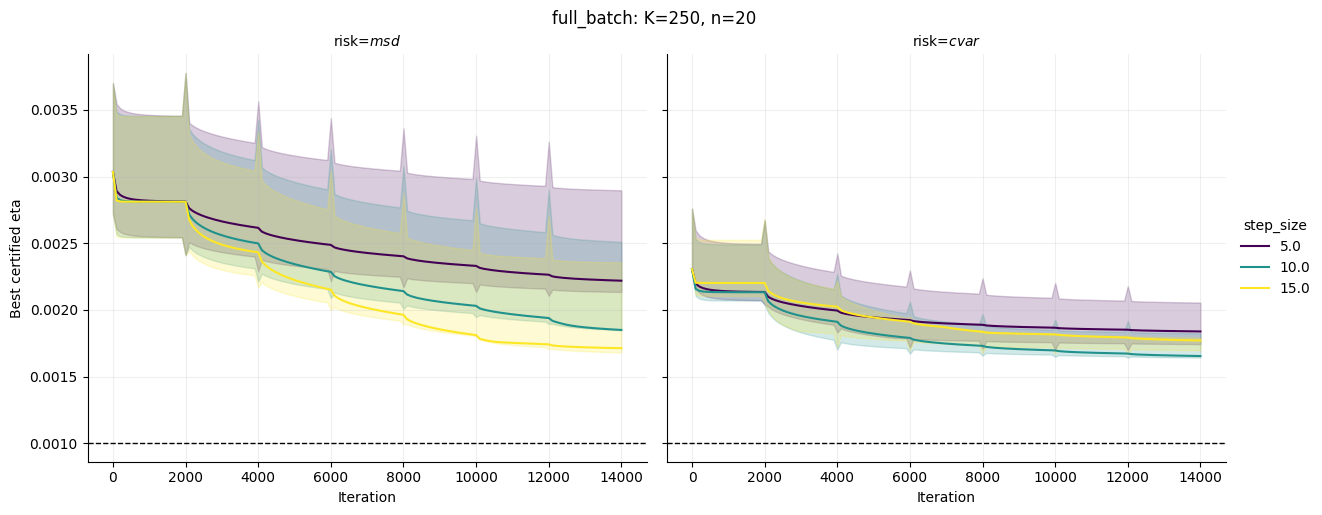

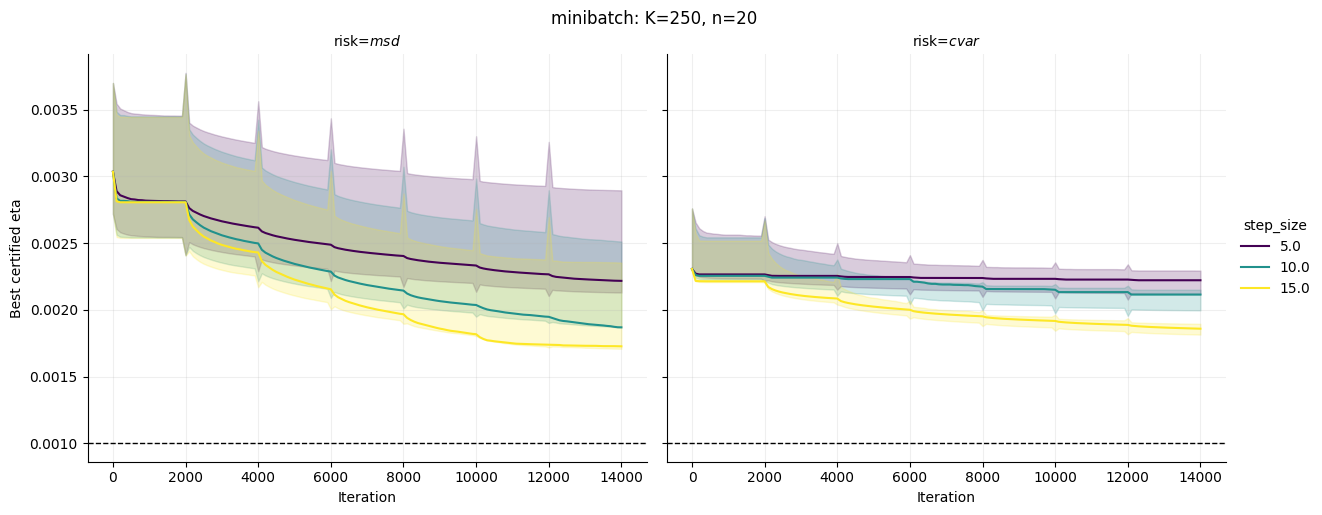

In [423]:
combinations = (
    history[["K", "n", "method"]].drop_duplicates().sort_values(["method", "K", "n"])
)

for row in combinations.itertuples(index=False):
    g = plot_eta_history(
        history,
        K=row.K,
        n=row.n,
        method=row.method,
    )
    if g is not None:
        plt.show()

In [405]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_eta_improvement(history, K, n, method):

    h = history[
        (history["K"] == K) & (history["n"] == n) & (history["method"] == method)
    ].copy()
    config = ["step_size"]
    groups = config + ["seed"]

    h = h.sort_values(groups + ["iteration"])
    h["best_eta"] = h.groupby(groups)["eta"].cummin()
    h["initial_eta"] = h.groupby(groups)["eta"].transform("first")
    h["eta_improvement_pct"] = (
        100 * (h["initial_eta"] - h["best_eta"]) / h["initial_eta"]
    )

    g = sns.relplot(
        data=h,
        x="iteration",
        y="eta_improvement_pct",
        # row="entropy_kappa",
        col="risk",
        hue="step_size",
        kind="line",
        palette="viridis",
        height=5,
        aspect=1.25,
    )

    for ax in g.axes.flat:
        ax.axhline(0, color="black", linewidth=1)
        ax.grid(alpha=0.2)

    g.set_axis_labels("Iteration", "Improvement over uniform (%)")
    g.set_titles(r"risk=${col_name}$")
    g.fig.suptitle(f"{method}: K={K}, n={n}", y=1.02)

    plt.show()

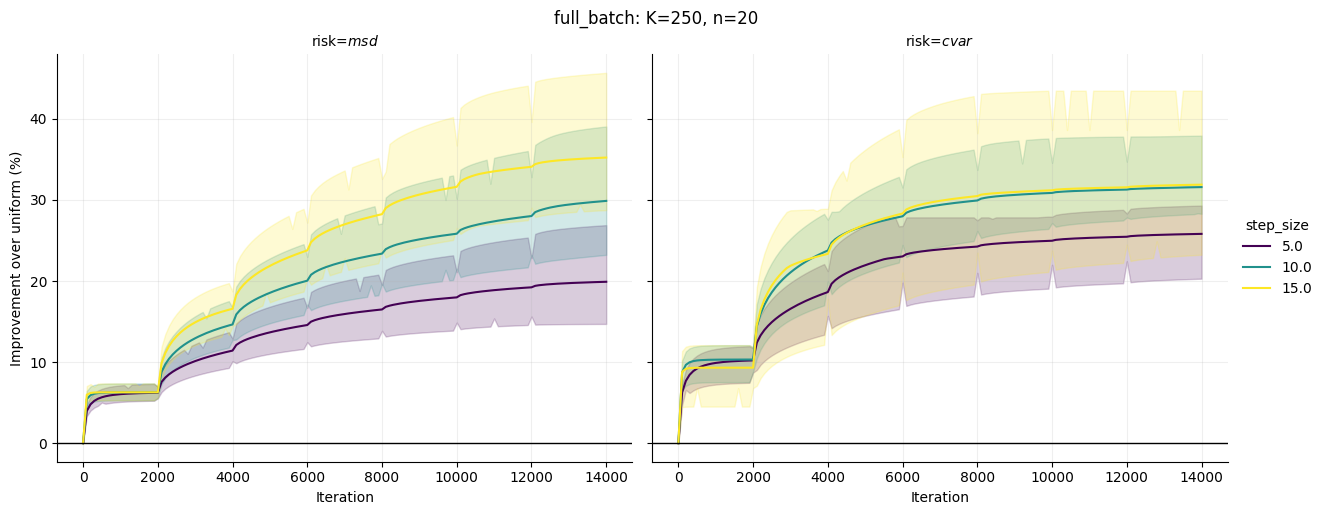

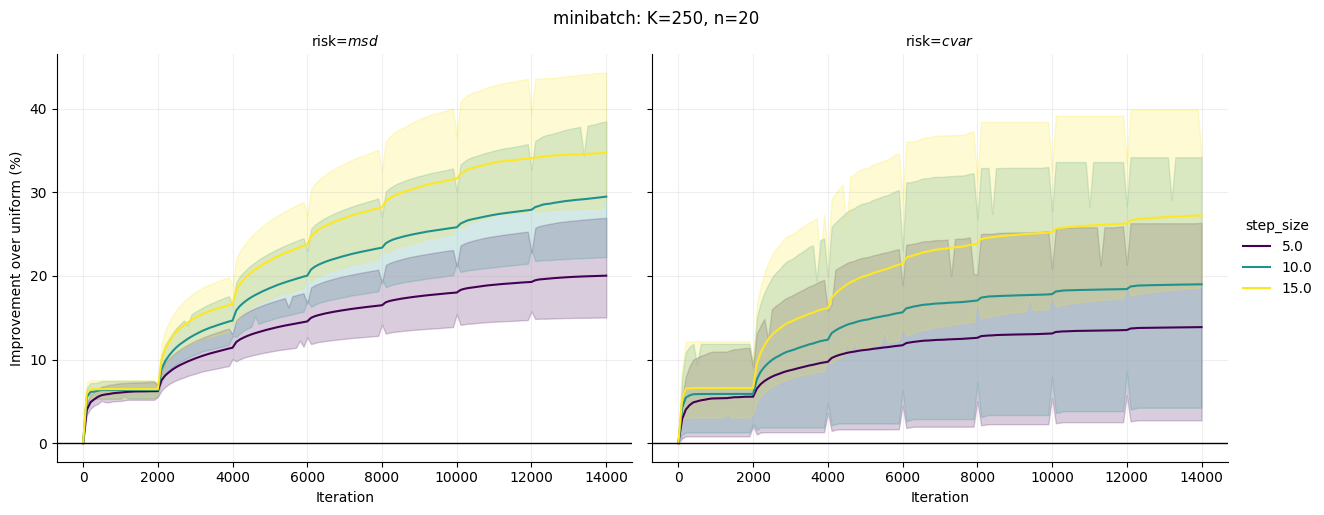

In [406]:
combinations = (
    history[["K", "n", "method"]].drop_duplicates().sort_values(["method", "K", "n"])
)

for row in combinations.itertuples(index=False):
    g = plot_eta_improvement(
        history,
        K=row.K,
        n=row.n,
        method=row.method,
    )
    if g is not None:
        plt.show()

In [407]:
def plot_eta_obj(history, K, n):

    h = history[(history["K"] == K) & (history["n"] == n)]
    cvar_resid_mask = (
        (history["risk"] == "cvar")
        & (history["entropy_kappa"] == 0.1)
        & (history["residual_norm"] < 0.6)
    )
    g = sns.relplot(
        data=h.loc[~cvar_resid_mask],
        x="residual_norm",
        y="eta",
        row="risk",
        hue="entropy_kappa",
        style="method",
        col="step_size",
        kind="scatter",
        height=3.2,
        facet_kws={"sharex": False, "sharey": True},
    )

    for ax in plt.gcf().axes:
        ax.grid(alpha=0.2)

    g.set_titles(r"risk={row_name}, step_size=${col_name}$")
    g.fig.suptitle(f"K={K}, n={n}", y=1.02)

    plt.show()

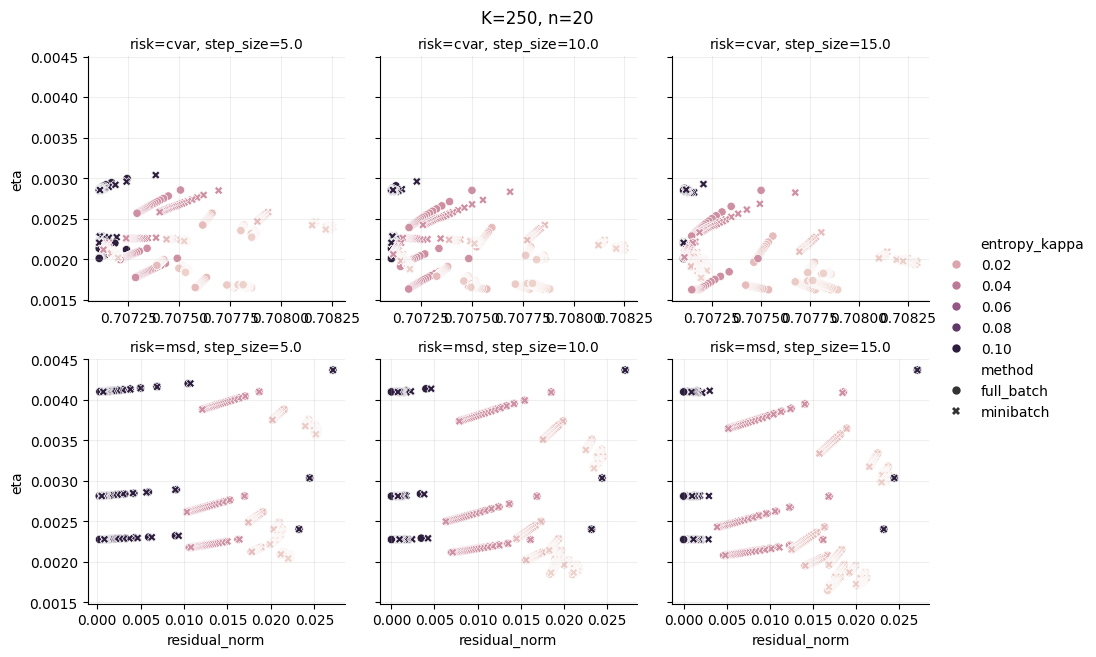

In [408]:
combinations = history[["K", "n"]].drop_duplicates().sort_values(["K", "n"])

for row in combinations.itertuples(index=False):
    g = plot_eta_obj(
        history,
        K=row.K,
        n=row.n,
    )
    if g is not None:
        plt.show()

## v3

In [429]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = Path("experiments/results")
if not results.exists():
    results = Path("results")

root = results / "stochastic/continuation_shards/v3"


def load_shards(suffix):
    frames = []
    for path in sorted(root.glob(f"*_{suffix}.csv")):
        if path.stat().st_size:
            frame = pd.read_csv(path)
            frame["shard"] = path.name.removesuffix(f"_{suffix}.csv")
            frames.append(frame)
    return pd.concat(frames, ignore_index=True)


summary = load_shards("summary")
history = load_shards("history")

warning_shards = {
    path.stem
    for path in (root / "logs").glob("*.log")
    if "RuntimeWarning" in path.read_text()
}
summary["had_runtime_warning"] = summary["shard"].isin(warning_shards)

long = pd.concat(
    [
        summary.assign(
            method=method,
            initial_step=summary["step_size"],
            eta=summary[f"{method}_eta"],
            success=summary[f"{method}_success"],
            time_s=summary[f"{method}_time_s"],
            iterations=summary[f"{method}_iterations"],
            stages=summary[f"{method}_stages_completed"],
            selected_stage=summary[f"{method}_selected_stage"],
        )
        for method in ["full_batch", "minibatch"]
    ],
    ignore_index=True,
)

long.groupby(["risk", "method", "initial_step"]).agg(
    reps=("eta", "size"),
    successes=("success", "sum"),
    min_eta=("eta", "min"),
    median_eta=("eta", "median"),
    max_eta=("eta", "max"),
    median_time_s=("time_s", "median"),
    median_iterations=("iterations", "median"),
    warning_rate=("had_runtime_warning", "mean"),
)

reps  successes   min_eta  median_eta   max_eta  \
risk method     initial_step                                                    
cvar full_batch 15.0             3          0  0.001628    0.001975  0.002125   
                20.0             3          0  0.001625    0.001796  0.001816   
                25.0             3          0  0.001624    0.001885  0.001891   
     minibatch  15.0             3          0  0.001975    0.002049  0.002234   
                20.0             3          0  0.001796    0.001876  0.001898   
                25.0             3          0  0.001885    0.001978  0.002049   
msd  full_batch 15.0             3          0  0.002009    0.002198  0.003482   
                20.0             3          0  0.001687    0.001739  0.003058   
                25.0             3          0  0.001899    0.002003  0.003225   
     minibatch  15.0             3          0  0.002009    0.002199  0.003474   
                20.0             3          0  0.001702    0.001750  0.003029   
                25.0             3          0  0.001905    0.002007  0.003203   

                              median_time_s  median_iterations  warning_rate  
risk method     initial_step                                                  
cvar full_batch 15.0             738.199056             4600.0           1.0  
                20.0             893.176097             5600.0           1.0  
                25.0             793.063920             4800.0           1.0  
     minibatch  15.0             794.105722             4600.0           1.0  
                20.0            1127.848556             7500.0           1.0  
                25.0             688.726722             4800.0           1.0  
msd  full_batch 15.0             342.608923             5000.0           1.0  
                20.0             578.127730             8000.0           1.0  
                25.0             420.104371             6200.0           1.0  
     minibatch  15.0             342.484024             4900.0           1.0  
                20.0             608.591235             7600.0           1.0  
                25.0             514.096325             6800.0           1.0

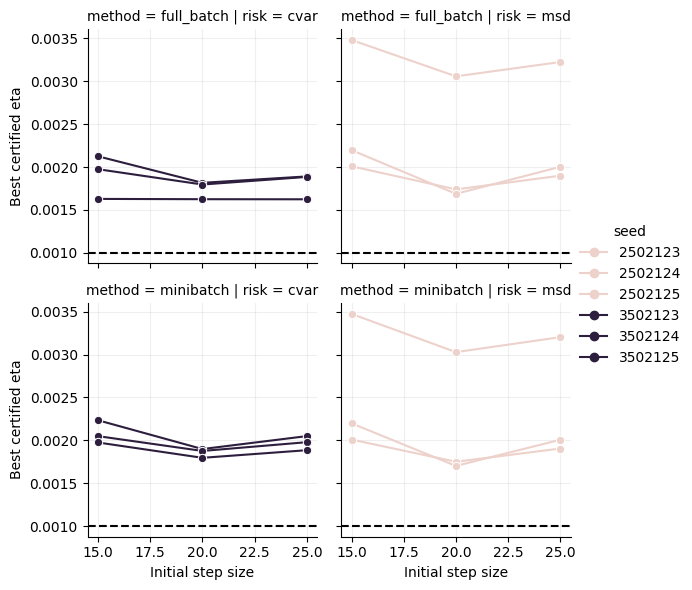

In [430]:
g = sns.relplot(
    data=long,
    x="initial_step",
    y="eta",
    row="method",
    col="risk",
    hue="seed",
    units="seed",
    estimator=None,
    marker="o",
    kind="line",
    height=3,
)
for ax in g.axes.flat:
    ax.axhline(1e-3, color="black", linestyle="--")
    ax.grid(alpha=0.2)
g.set_axis_labels("Initial step size", "Best certified eta")

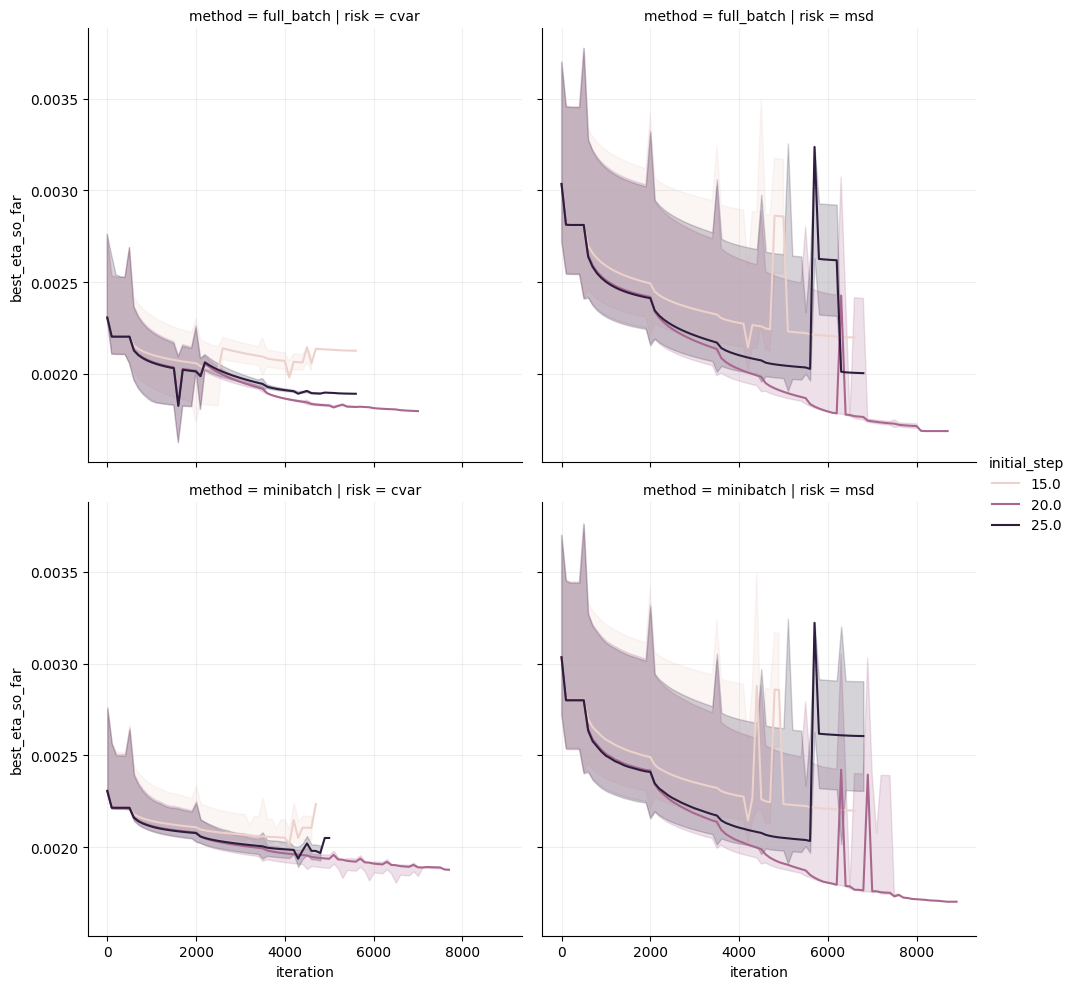

In [433]:
initial_steps = summary[["shard", "step_size"]].rename(
    columns={"step_size": "initial_step"}
)
history = history.merge(initial_steps, on="shard", validate="many_to_one")
history = history.sort_values(["shard", "method", "iteration"])
history["best_eta_so_far"] = history.groupby(["shard", "method"])["eta"].cummin()

g = sns.relplot(
    data=history,
    x="iteration",
    y="best_eta_so_far",
    row="method",
    col="risk",
    hue="initial_step",
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    height=5,
)
for ax in g.axes.flat:
    # ax.axhline(1e-3, color="black", linestyle="--")
    ax.grid(alpha=0.2)